# Pneumonia Detection from Chest X-Ray Images Using CNN

## Medical Image Classification Project

**Name:** Md. Atik Hasan Rahat  
**Student ID:** Your ID  

### Objective
The objective of this project is to develop a Convolutional Neural Network (CNN)
for detecting pneumonia from chest X-ray images.

### Dataset
Chest X-Ray Images (Pneumonia) dataset from Kaggle.

### Classes
- NORMAL
- PNEUMONIA

### Task
Binary Image Classification

In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

gpu = tf.config.list_physical_devices('GPU')

if gpu:
    print("GPU available:", gpu)
else:
    print("GPU not detected. Change Colab runtime to GPU.")

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip -q install kagglehub

In [3]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia",
    output_dir="/content/data"
)

print("Dataset downloaded to:", dataset_path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset downloaded to: /kaggle/input/chest-xray-pneumonia


In [4]:
from pathlib import Path

# Use the path returned by kagglehub
search_root = Path(dataset_path)

print("Searching inside:", search_root)

candidates = []

for folder in search_root.rglob("chest_xray"):
    if (folder / "train").exists() and (folder / "test").exists():
        candidates.append(folder)

if not candidates:
    raise FileNotFoundError(
        f"Could not locate the chest_xray dataset folder inside {search_root}"
    )

BASE_DIR = candidates[0]

print("Dataset directory:", BASE_DIR)

Searching inside: /kaggle/input/chest-xray-pneumonia
Dataset directory: /kaggle/input/chest-xray-pneumonia/chest_xray


In [5]:
TRAIN_DIR = BASE_DIR / "train"
VAL_DIR   = BASE_DIR / "val"
TEST_DIR  = BASE_DIR / "test"

print("Training directory   :", TRAIN_DIR)
print("Validation directory :", VAL_DIR)
print("Testing directory    :", TEST_DIR)

print("\nDo folders exist?")
print("Train:", TRAIN_DIR.exists())
print("Validation:", VAL_DIR.exists())
print("Test:", TEST_DIR.exists())

Training directory   : /kaggle/input/chest-xray-pneumonia/chest_xray/train
Validation directory : /kaggle/input/chest-xray-pneumonia/chest_xray/val
Testing directory    : /kaggle/input/chest-xray-pneumonia/chest_xray/test

Do folders exist?
Train: True
Validation: True
Test: True


In [6]:
print("Train folders:")
for folder in TRAIN_DIR.iterdir():
    if folder.is_dir():
        print("-", folder.name)

print("\nTest folders:")
for folder in TEST_DIR.iterdir():
    if folder.is_dir():
        print("-", folder.name)

Train folders:
- PNEUMONIA
- NORMAL

Test folders:
- PNEUMONIA
- NORMAL


## Exploratory Data Analysis (EDA)

First, we examine the number of chest X-ray images available in each class and dataset split.

In [7]:
def count_images(directory):
    counts = {}

    for class_name in ["NORMAL", "PNEUMONIA"]:
        class_dir = directory / class_name

        image_files = [
            f for f in class_dir.iterdir()
            if f.suffix.lower() in [".jpeg", ".jpg", ".png"]
        ]

        counts[class_name] = len(image_files)

    return counts


train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)
test_counts = count_images(TEST_DIR)

print("Training set:", train_counts)
print("Validation set:", val_counts)
print("Test set:", test_counts)

print("\nTotal training images:", sum(train_counts.values()))
print("Total validation images:", sum(val_counts.values()))
print("Total test images:", sum(test_counts.values()))

Training set: {'NORMAL': 1341, 'PNEUMONIA': 3875}
Validation set: {'NORMAL': 8, 'PNEUMONIA': 8}
Test set: {'NORMAL': 234, 'PNEUMONIA': 390}

Total training images: 5216
Total validation images: 16
Total test images: 624


### Class Distribution

The number of images in each class is visualized to identify possible class imbalance in the dataset.

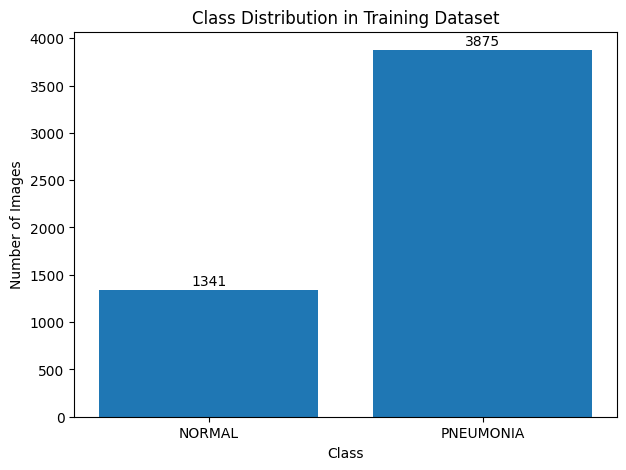

In [8]:
import matplotlib.pyplot as plt

classes = ["NORMAL", "PNEUMONIA"]

normal_count = train_counts["NORMAL"]
pneumonia_count = train_counts["PNEUMONIA"]

counts = [normal_count, pneumonia_count]

plt.figure(figsize=(7, 5))

bars = plt.bar(classes, counts)

plt.title("Class Distribution in Training Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")

for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        str(count),
        ha="center"
    )

plt.show()

In [9]:
total_train = sum(train_counts.values())

normal_percentage = (train_counts["NORMAL"] / total_train) * 100
pneumonia_percentage = (train_counts["PNEUMONIA"] / total_train) * 100

print(f"NORMAL: {normal_percentage:.2f}%")
print(f"PNEUMONIA: {pneumonia_percentage:.2f}%")

NORMAL: 25.71%
PNEUMONIA: 74.29%


The training dataset is imbalanced, with approximately 74% of the images
belonging to the PNEUMONIA class and 26% belonging to the NORMAL class.
Therefore, evaluation metrics such as precision, recall, F1-score, and
ROC-AUC will be considered in addition to accuracy.

### Sample Chest X-Ray Images

The following images show examples from the NORMAL and PNEUMONIA classes.

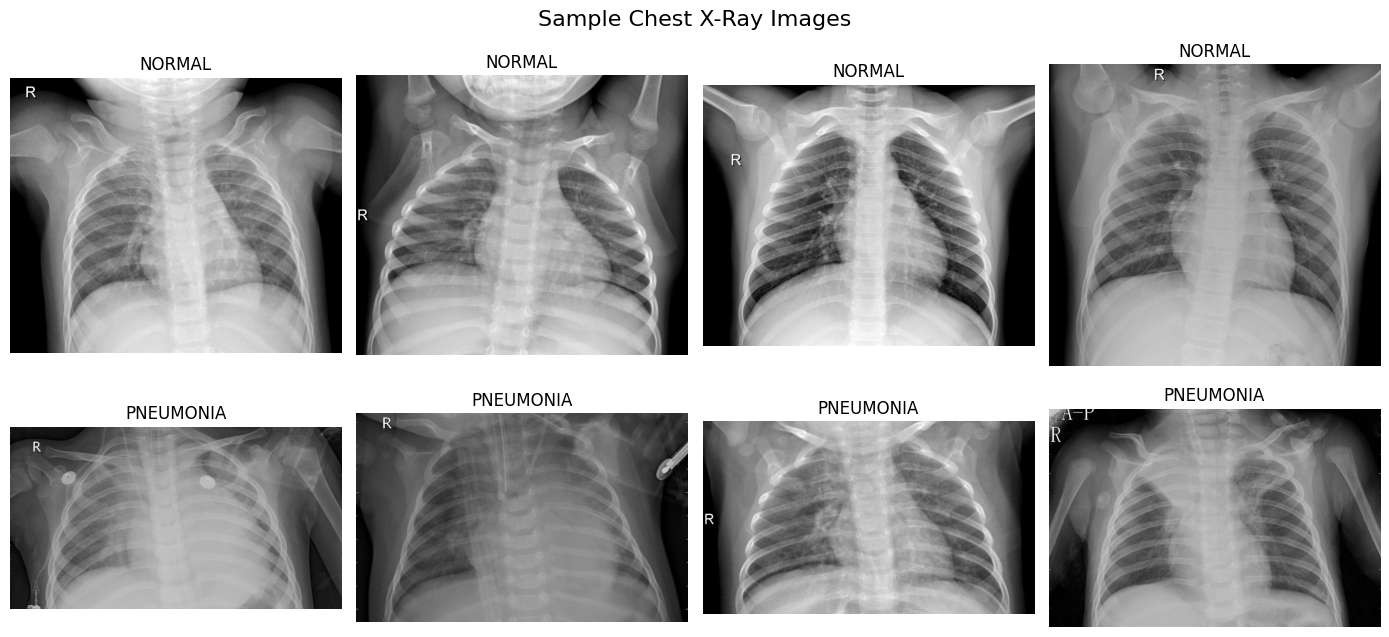

In [10]:
from PIL import Image
import random

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

class_names = ["NORMAL", "PNEUMONIA"]

for row, class_name in enumerate(class_names):

    image_files = [
        f for f in (TRAIN_DIR / class_name).iterdir()
        if f.suffix.lower() in [".jpeg", ".jpg", ".png"]
    ]

    selected_images = random.sample(image_files, 4)

    for col, image_path in enumerate(selected_images):

        image = Image.open(image_path)

        axes[row, col].imshow(image, cmap="gray")
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.suptitle("Sample Chest X-Ray Images", fontsize=16)
plt.tight_layout()
plt.show()

### Image Dimension Analysis

The original chest X-ray images have different spatial dimensions. Therefore,
the image dimensions are examined before resizing them to a uniform size for
CNN training.

In [11]:
from PIL import Image
import pandas as pd

image_info = []

for class_name in ["NORMAL", "PNEUMONIA"]:

    class_dir = TRAIN_DIR / class_name

    for image_path in class_dir.iterdir():

        if image_path.suffix.lower() in [".jpeg", ".jpg", ".png"]:

            with Image.open(image_path) as img:

                width, height = img.size

                image_info.append({
                    "Class": class_name,
                    "Width": width,
                    "Height": height,
                    "Mode": img.mode
                })

image_df = pd.DataFrame(image_info)

print("Number of images checked:", len(image_df))

image_df.head()

Number of images checked: 5216


,Class,Width,Height,Mode
0,NORMAL,1336,1128,L
1,NORMAL,1400,1260,L
2,NORMAL,1218,1032,L
3,NORMAL,1782,1433,L
4,NORMAL,1574,1129,L


In [12]:
print("Image Width Statistics")
print(image_df["Width"].describe())

print("\nImage Height Statistics")
print(image_df["Height"].describe())

Image Width Statistics
count    5216.000000
mean     1320.610813
std       355.298743
min       384.000000
25%      1056.000000
50%      1284.000000
75%      1552.000000
max      2916.000000
Name: Width, dtype: float64

Image Height Statistics
count    5216.000000
mean      968.074770
std       378.855691
min       127.000000
25%       688.000000
50%       888.000000
75%      1187.750000
max      2663.000000
Name: Height, dtype: float64


In [13]:
print("Minimum image size:",
      image_df["Width"].min(), "x",
      image_df["Height"].min())

print("Maximum image size:",
      image_df["Width"].max(), "x",
      image_df["Height"].max())

print("Median image size:",
      int(image_df["Width"].median()), "x",
      int(image_df["Height"].median()))

print("\nImage modes:")
print(image_df["Mode"].value_counts())

Minimum image size: 384 x 127
Maximum image size: 2916 x 2663
Median image size: 1284 x 888

Image modes:
Mode
L      4933
RGB     283
Name: count, dtype: int64


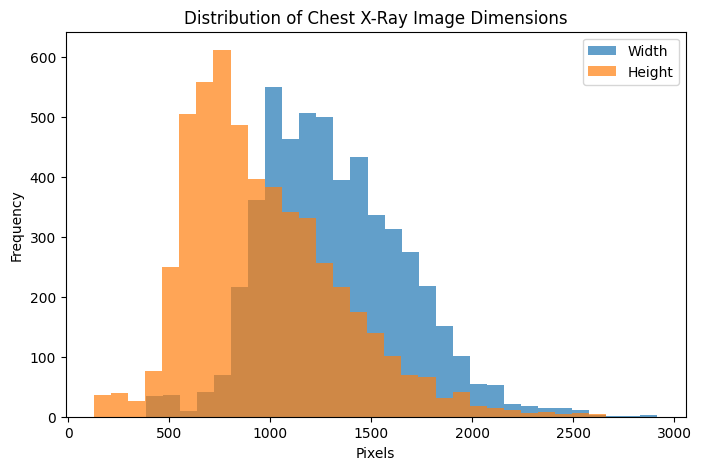

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(image_df["Width"], bins=30, alpha=0.7, label="Width")
plt.hist(image_df["Height"], bins=30, alpha=0.7, label="Height")

plt.title("Distribution of Chest X-Ray Image Dimensions")
plt.xlabel("Pixels")
plt.ylabel("Frequency")
plt.legend()

plt.show()

#### Observation

The chest X-ray images have varying spatial dimensions. CNN models require
inputs with a consistent shape; therefore, all images will be resized to
224 × 224 pixels during preprocessing.

The images are primarily grayscale chest radiographs. For this project,
the images will be processed into a consistent format before being supplied
to the CNN.

## Data Splitting

The original dataset contains 5,216 training images, only 16 validation images,
and 624 test images. Since the original validation set is too small for reliable
model monitoring, a new validation set is created from the original training data.

An 80:20 stratified split is used so that the proportion of NORMAL and PNEUMONIA
images remains similar in both the training and validation sets.

The original test set is kept completely separate and will only be used for final
model evaluation.

In [15]:
import pandas as pd

train_files = []

for class_name in ["NORMAL", "PNEUMONIA"]:

    class_dir = TRAIN_DIR / class_name

    for image_path in class_dir.iterdir():

        if image_path.suffix.lower() in [".jpeg", ".jpg", ".png"]:

            train_files.append({
                "filepath": str(image_path),
                "label": class_name
            })

train_df = pd.DataFrame(train_files)

print("Total images:", len(train_df))
print()
print(train_df["label"].value_counts())

train_df.head()

Total images: 5216

label
PNEUMONIA    3875
NORMAL       1341
Name: count, dtype: int64


,filepath,label
0,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
1,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
2,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
3,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
4,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL


In [16]:
from sklearn.model_selection import train_test_split

train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df["label"]
)

print("Training images:", len(train_split_df))
print("Validation images:", len(val_split_df))

Training images: 4172
Validation images: 1044


In [17]:
print("Training class distribution:")
print(train_split_df["label"].value_counts())

print("\nValidation class distribution:")
print(val_split_df["label"].value_counts())

Training class distribution:
label
PNEUMONIA    3099
NORMAL       1073
Name: count, dtype: int64

Validation class distribution:
label
PNEUMONIA    776
NORMAL       268
Name: count, dtype: int64


In [18]:
print("Training percentages:")
print(
    train_split_df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nValidation percentages:")
print(
    val_split_df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training percentages:
label
PNEUMONIA    74.28
NORMAL       25.72
Name: proportion, dtype: float64

Validation percentages:
label
PNEUMONIA    74.33
NORMAL       25.67
Name: proportion, dtype: float64


In [19]:
test_files = []

for class_name in ["NORMAL", "PNEUMONIA"]:

    class_dir = TEST_DIR / class_name

    for image_path in class_dir.iterdir():

        if image_path.suffix.lower() in [".jpeg", ".jpg", ".png"]:

            test_files.append({
                "filepath": str(image_path),
                "label": class_name
            })

test_df = pd.DataFrame(test_files)

print("Total test images:", len(test_df))
print()
print(test_df["label"].value_counts())

Total test images: 624

label
PNEUMONIA    390
NORMAL       234
Name: count, dtype: int64


In [20]:
label_map = {
    "NORMAL": 0,
    "PNEUMONIA": 1
}

train_split_df = train_split_df.copy()
val_split_df = val_split_df.copy()
test_df = test_df.copy()

train_split_df["label_encoded"] = train_split_df["label"].map(label_map)
val_split_df["label_encoded"] = val_split_df["label"].map(label_map)
test_df["label_encoded"] = test_df["label"].map(label_map)

In [21]:
train_split_df.head()

,filepath,label,label_encoded
99,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,0
1284,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,0
5142,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA,1
1365,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA,1
2649,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA,1


In [22]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

In [23]:
import tensorflow as tf

def load_and_preprocess_image(filepath, label):

    # Read image file
    image = tf.io.read_file(filepath)

    # Decode JPEG as grayscale
    image = tf.image.decode_jpeg(
        image,
        channels=1
    )

    # Resize
    image = tf.image.resize(
        image,
        [IMG_HEIGHT, IMG_WIDTH]
    )

    # Convert to float32
    image = tf.cast(image, tf.float32)

    # Normalize pixel values from [0, 255] to [0, 1]
    image = image / 255.0

    return image, label

In [24]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_split_df["filepath"].values,
        train_split_df["label_encoded"].values
    )
)

train_ds = train_ds.shuffle(
    buffer_size=len(train_split_df),
    seed=SEED
)

train_ds = train_ds.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.batch(BATCH_SIZE)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

In [25]:
val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_split_df["filepath"].values,
        val_split_df["label_encoded"].values
    )
)

val_ds = val_ds.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.batch(BATCH_SIZE)

val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

In [26]:
test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_df["filepath"].values,
        test_df["label_encoded"].values
    )
)

test_ds = test_ds.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.batch(BATCH_SIZE)

test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [27]:
for images, labels in train_ds.take(1):

    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Image batch shape: (32, 224, 224, 1)
Label batch shape: (32,)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


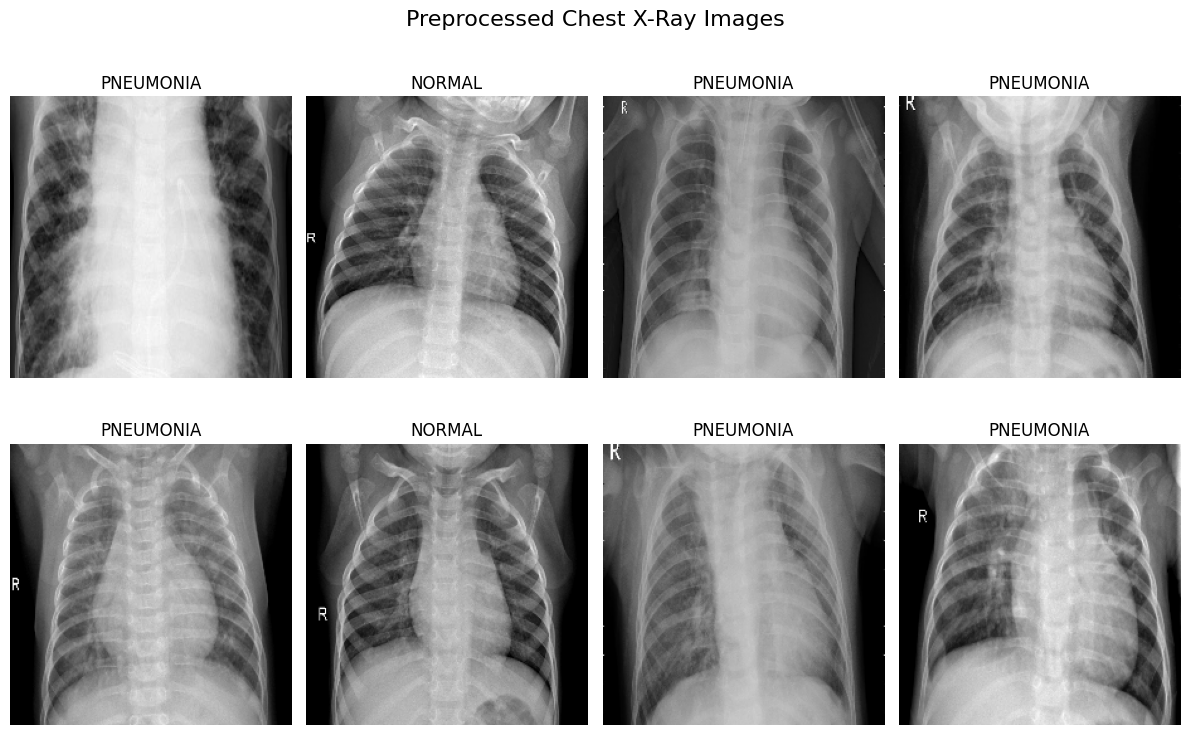

In [28]:
plt.figure(figsize=(12, 8))

class_names = ["NORMAL", "PNEUMONIA"]

for images, labels in train_ds.take(1):

    for i in range(8):

        plt.subplot(2, 4, i + 1)

        plt.imshow(
            images[i].numpy().squeeze(),
            cmap="gray"
        )

        label = int(labels[i].numpy())

        plt.title(class_names[label])
        plt.axis("off")

plt.suptitle("Preprocessed Chest X-Ray Images", fontsize=16)

plt.tight_layout()
plt.show()

## Data Augmentation

To improve model generalization and reduce overfitting, mild data augmentation
is applied to the training images.

Because chest X-rays contain anatomically meaningful left-right orientation,
horizontal flipping is not used. Instead, small rotations, translations,
zooming, and contrast variations are applied.

In [29]:
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.02),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),
    tf.keras.layers.RandomContrast(0.10)
], name="data_augmentation")

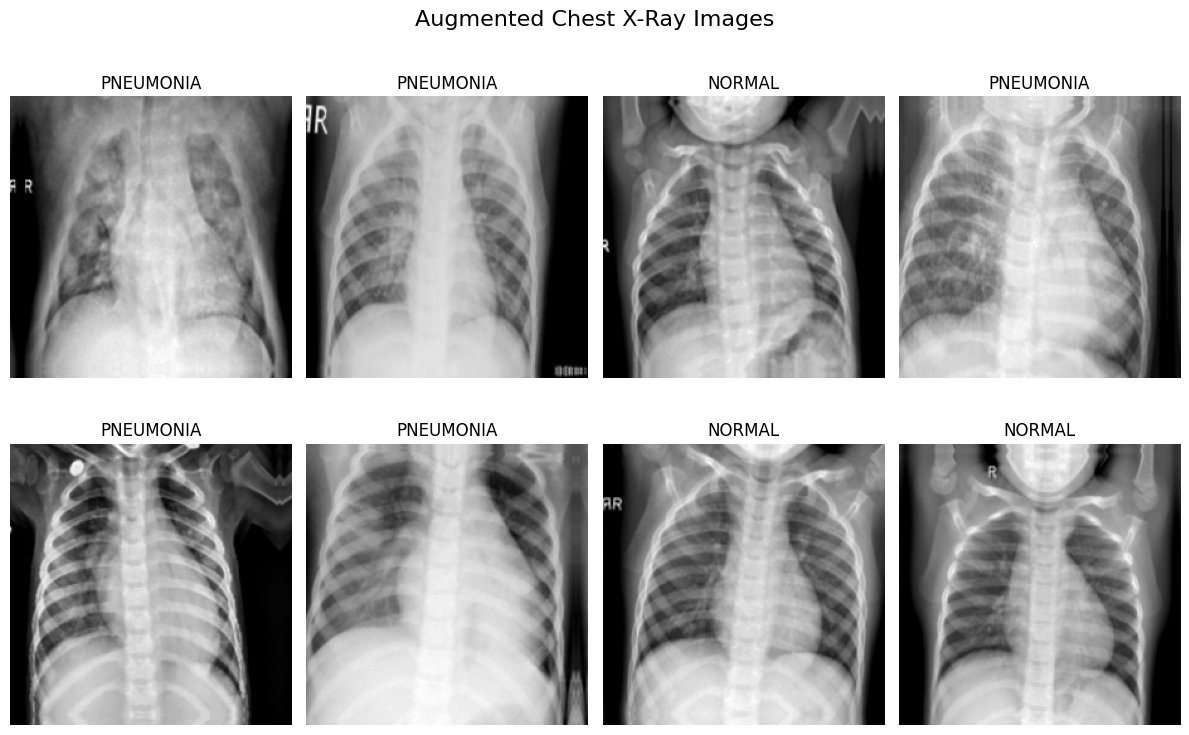

In [30]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):

    augmented_images = data_augmentation(
        images,
        training=True
    )

    for i in range(8):

        plt.subplot(2, 4, i + 1)

        plt.imshow(
            augmented_images[i].numpy().squeeze(),
            cmap="gray"
        )

        label = int(labels[i].numpy())

        plt.title(class_names[label])
        plt.axis("off")

plt.suptitle("Augmented Chest X-Ray Images", fontsize=16)
plt.tight_layout()
plt.show()

## Handling Class Imbalance

The training dataset contains considerably more PNEUMONIA images than NORMAL
images. Class weights are therefore calculated so that errors involving the
minority class receive greater importance during model training.

In [31]:
import numpy as np

from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_split_df["label_encoded"].values
)

class_weights = {
    0: class_weights_array[0],
    1: class_weights_array[1]
}

print("Class weights:")
print("NORMAL (0):", class_weights[0])
print("PNEUMONIA (1):", class_weights[1])

Class weights:
NORMAL (0): 1.9440820130475303
PNEUMONIA (1): 0.6731203614069055


## CNN Model Architecture

A custom Convolutional Neural Network (CNN) is developed to classify chest
X-ray images into two categories: NORMAL and PNEUMONIA.

The network contains four convolutional blocks. Each block uses a convolution
layer for feature extraction, batch normalization for stable training, and
max-pooling for spatial dimension reduction.

After convolutional feature extraction, Global Average Pooling is used,
followed by a fully connected layer and dropout regularization.

Finally, a sigmoid output neuron produces the probability of pneumonia.

### Architecture
- Input: 224 × 224 × 1 grayscale image
- Conv2D: 32 filters
- Batch Normalization
- Max Pooling
- Conv2D: 64 filters
- Batch Normalization
- Max Pooling
- Conv2D: 128 filters
- Batch Normalization
- Max Pooling
- Conv2D: 256 filters
- Batch Normalization
- Max Pooling
- Global Average Pooling
- Dense: 128 neurons
- Dropout: 0.4
- Output: 1 neuron with sigmoid activation

In [32]:
model = tf.keras.Sequential([

    # Input layer
    tf.keras.layers.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, 1)
    ),

    # Data augmentation
    data_augmentation,

    # Convolutional Block 1
    tf.keras.layers.Conv2D(
        32,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convolutional Block 2
    tf.keras.layers.Conv2D(
        64,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convolutional Block 3
    tf.keras.layers.Conv2D(
        128,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convolutional Block 4
    tf.keras.layers.Conv2D(
        256,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convert feature maps into feature vector
    tf.keras.layers.GlobalAveragePooling2D(),

    # Fully connected layer
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    # Regularization
    tf.keras.layers.Dropout(0.4),

    # Output layer
    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,785 (1.61 MB)

 Trainable params: 421,825 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

### Model Compilation

The model is trained using the Adam optimizer with an initial learning rate
of 0.001. Binary cross-entropy is used as the loss function because the task
is binary classification.

Accuracy, precision, recall, and ROC-AUC are monitored during training.
Using multiple metrics is particularly important because the dataset is
imbalanced.

In [34]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)

In [35]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="/content/best_pneumonia_cnn.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [36]:
print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU available:", gpus)
else:
    print("GPU NOT available")

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Model Training

The CNN is trained for a maximum of 20 epochs using a batch size of 32.
Class weights are applied to reduce the effect of class imbalance.

Early stopping and learning-rate reduction are used to reduce overfitting
and improve convergence.

In [37]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.8087 - auc: 0.8937 - loss: 0.4031 - precision: 0.9419 - recall: 0.7909
Epoch 1: val_loss improved from None to 3.64402, saving model to /content/best_pneumonia_cnn.keras

Epoch 1: finished saving model to /content/best_pneumonia_cnn.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 39s 220ms/step - accuracy: 0.8545 - auc: 0.9311 - loss: 0.3280 - precision: 0.9598 - recall: 0.8393 - val_accuracy: 0.7433 - val_auc: 0.5000 - val_loss: 3.6440 - val_precision: 0.7433 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.8943 - auc: 0.9604 - loss: 0.2495 - precision: 0.9769 - recall: 0.8777
Epoch 2: val_loss did not improve from 3.64402
131/131 ━━━━━━━━━━━━━━━━━━━━ 30s 227ms/step - accuracy: 0.8888 - auc: 0.9572 - loss: 0.2575 - precision: 0.9710 - recall: 0.8764 - val_accuracy: 0.7433 - val_auc: 0.5000 - val_loss: 4.4414 - val_precision: 0.7433 - val_recall: 1.0000 - learning_rate

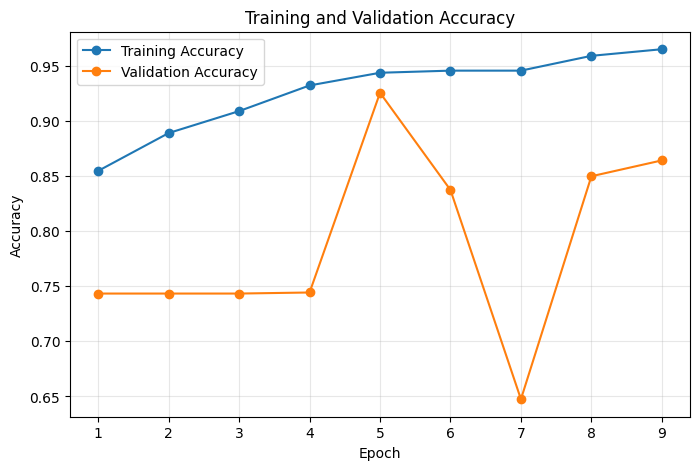

In [38]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

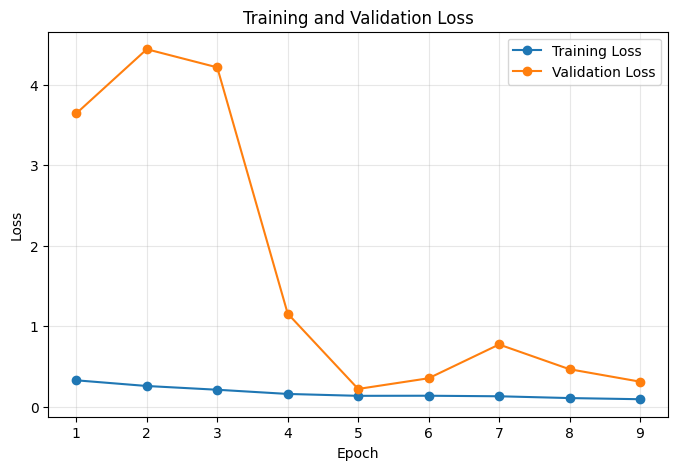

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [40]:
best_model = tf.keras.models.load_model(
    "/content/best_pneumonia_cnn.keras"
)

print("Best model loaded successfully.")

Best model loaded successfully.


In [41]:
test_results = best_model.evaluate(
    test_ds,
    verbose=1
)

print("\nFinal Test Results")
print("-------------------------")

for metric_name, metric_value in zip(
    best_model.metrics_names,
    test_results
):
    print(f"{metric_name}: {metric_value:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 179ms/step - accuracy: 0.6779 - auc: 0.8307 - loss: 1.4670 - precision: 0.6621 - recall: 0.9897

Final Test Results
-------------------------
loss: 1.4670
compile_metrics: 0.6779


In [42]:
test_results = best_model.evaluate(
    test_ds,
    return_dict=True,
    verbose=1
)

print("\nFinal Test Results")
print("-------------------------")

for metric, value in test_results.items():
    print(f"{metric}: {value:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.6779 - auc: 0.8307 - loss: 1.4670 - precision: 0.6621 - recall: 0.9897

Final Test Results
-------------------------
accuracy: 0.6779
auc: 0.8307
loss: 1.4670
precision: 0.6621
recall: 0.9897


In [43]:
y_prob = best_model.predict(
    test_ds,
    verbose=1
).ravel()

y_pred = (y_prob >= 0.5).astype(int)

y_true = test_df["label_encoded"].values

print("Number of test samples:", len(y_true))
print("Number of predictions:", len(y_pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step
Number of test samples: 624
Number of predictions: 624


In [44]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1-score :", f1_score(y_true, y_pred))
print("ROC-AUC  :", roc_auc_score(y_true, y_prob))

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["NORMAL", "PNEUMONIA"],
        digits=4
    )
)

Accuracy : 0.6778846153846154
Precision: 0.6620926243567753
Recall   : 0.9897435897435898
F1-score : 0.7934224049331963
ROC-AUC  : 0.9110508437431515

Classification Report:

              precision    recall  f1-score   support

      NORMAL     0.9024    0.1581    0.2691       234
   PNEUMONIA     0.6621    0.9897    0.7934       390

    accuracy                         0.6779       624
   macro avg     0.7823    0.5739    0.5313       624
weighted avg     0.7522    0.6779    0.5968       624



<Figure size 600x500 with 0 Axes>

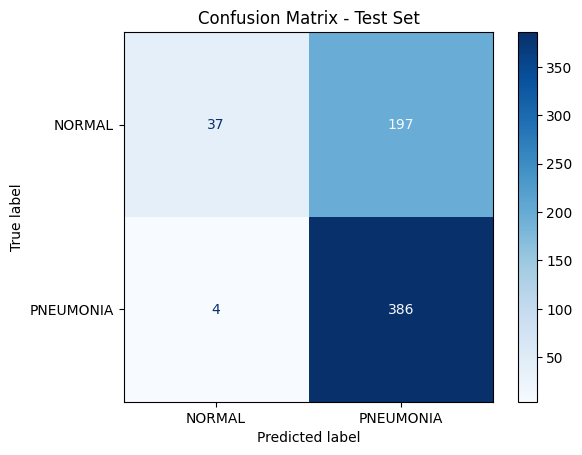

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "PNEUMONIA"]
)

plt.figure(figsize=(6, 5))

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Test Set")
plt.show()

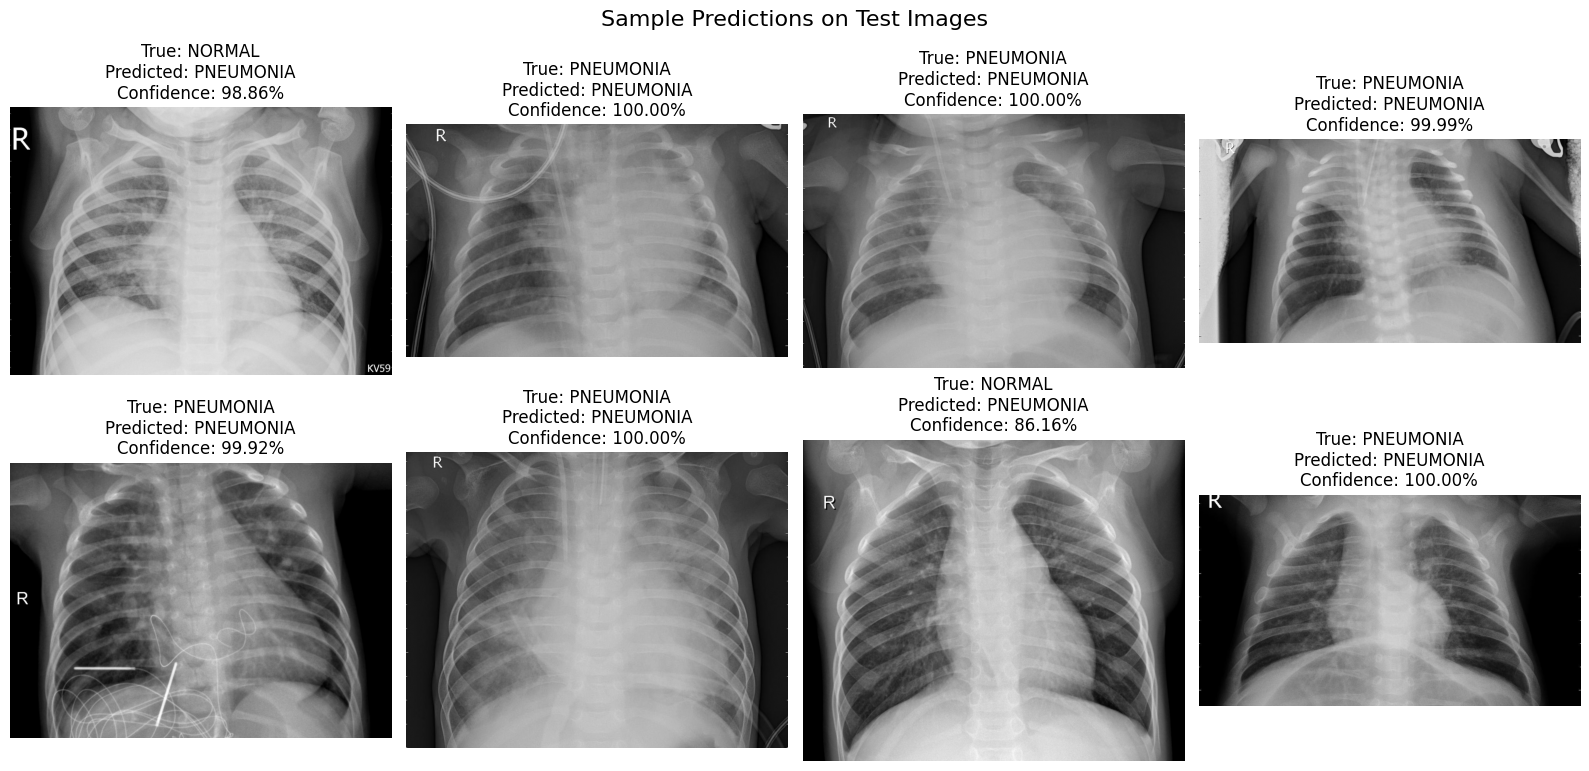

In [46]:
# Sample Model Predictions

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Select 8 random test images
rng = np.random.default_rng(42)

sample_indices = rng.choice(
    len(test_df),
    size=8,
    replace=False
)

plt.figure(figsize=(16, 8))

for plot_number, idx in enumerate(sample_indices):

    # Original image
    image_path = test_df.iloc[idx]["filepath"]
    image = Image.open(image_path).convert("L")

    # True class
    true_label = test_df.iloc[idx]["label"]

    # Predicted class
    predicted_label = (
        "PNEUMONIA"
        if y_pred[idx] == 1
        else "NORMAL"
    )

    # Prediction confidence
    if y_pred[idx] == 1:
        confidence = y_prob[idx]
    else:
        confidence = 1 - y_prob[idx]

    plt.subplot(2, 4, plot_number + 1)

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.title(
        f"True: {true_label}\n"
        f"Predicted: {predicted_label}\n"
        f"Confidence: {confidence:.2%}"
    )

    plt.axis("off")

plt.suptitle(
    "Sample Predictions on Test Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Results and Discussion

The custom CNN was evaluated on the independent test set containing
624 chest X-ray images.

Using a classification threshold of 0.5, the model achieved an accuracy
of 67.79%, precision of 66.21%, recall of 98.97%, and F1-score of
79.34%. The ROC-AUC calculated from the model's prediction probabilities
was approximately 91.11%.

The model achieved very high recall for the PNEUMONIA class (98.97%),
indicating that it successfully detected almost all pneumonia cases.
However, the recall for the NORMAL class was only 15.81%, showing that
many normal chest X-rays were incorrectly classified as pneumonia.

The relatively high ROC-AUC indicates that the model has good ability
to distinguish between the two classes across different classification
thresholds. However, the performance at the default threshold of 0.5
is strongly biased toward detecting pneumonia, resulting in a large
number of false-positive predictions for normal cases.

Overall, the custom CNN learned useful discriminative features from
the chest X-ray images and achieved high sensitivity for pneumonia
detection. Further improvement, such as decision-threshold optimization
or additional model tuning, could help improve the balance between
pneumonia detection and correct classification of normal images.